# Notebook 07 — PF03007 (WS/DGAT) Distribution Across Bacterial Genomes

**Author:** Virginia Galván, PhD

**Reference:** Chapter I, Sections 6.5 (Materials & Methods) and 7.3.4 (Results), Figure 8.

Notebooks 04–06 surveyed WS/DGAT biosynthetic potential across environmental metagenomes (marine, terrestrial, deep-ocean). This notebook takes a complementary, genome-centric approach: a function-based search for the PF03007 domain across the full set of bacterial genomes available in IMG/M, to characterize which taxonomic groups actually carry this biosynthetic potential and how many gene copies they carry per genome.

Unlike the metagenome surveys, this analysis does not use the 12-marker relative-abundance normalization — a genome is a fixed, complete unit, so PF03007 presence and copy number can be read directly, without correcting for sequencing depth or community composition.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100


## 1. Load data

Genome-level PF03007 domain counts and NCBI taxonomy (phylum, class) for bacterial genomes in IMG/M, identified via a function search for the PF03007 domain. Each row is one genome, uniquely identified by its **IMG Genome ID**.


In [2]:
DATA_DIR = "data/"
try:
    genomes = pd.read_csv(DATA_DIR + "bacterial_genomes_pf03007_repo1.csv")
except FileNotFoundError:
    genomes = pd.read_csv("bacterial_genomes_pf03007_repo1.csv")

# IMG/M labels a genome's class as "unclassified" whenever its phylum is known but its
# class has not been resolved. Since this placeholder recurs independently within many
# phyla, it is disambiguated by phylum immediately on load (e.g. "unclassified (Actinomycetota)"),
# so it is never treated as a single class shared across phyla.
genomes['class'] = genomes.apply(
    lambda r: f"unclassified ({r['phylum']})" if r['class'] == 'unclassified' else r['class'],
    axis=1
)

is_unresolved = genomes['class'].str.startswith('unclassified (')
n_named_classes = genomes.loc[~is_unresolved, 'class'].nunique()
n_unresolved_groups = genomes.loc[is_unresolved, 'class'].nunique()

print(f"Genomes: {genomes.shape[0]:,}")
print(f"Total PF03007 gene copies: {genomes['pf03007_count'].sum():,}")
print(f"Bacterial phyla represented: {genomes['phylum'].nunique()}")
print(f"Bacterial classes represented: {n_named_classes} named + {n_unresolved_groups} phylum-level 'unclassified' placeholders ({n_named_classes + n_unresolved_groups} total)")
genomes.head()


Genomes: 18,392
Total PF03007 gene copies: 81,868
Bacterial phyla represented: 19
Bacterial classes represented: 32 named + 11 phylum-level 'unclassified' placeholders (43 total)


,img_genome_id,genome_name,phylum,class,pf03007_count,sequencing_status,genome_size_bp,gene_count,study_name,sequencing_center
0,637000001,Candidatus Koribacter versatilis Ellin345,Acidobacteriota,Terriglobia,1,Finished,5650368,4837,Acidobacteria Uncultured,DOE Joint Genome Institute (JGI)
1,637000002,Acinetobacter baylyi ADP1,Pseudomonadota,Gammaproteobacteria,1,Finished,3598621,3433,Acinetobacter baylyi ADP1,CEA Genoscope
2,637000004,Alcanivorax borkumensis SK2,Pseudomonadota,Gammaproteobacteria,2,Finished,3120143,2817,Alcanivorax borkumensis SK2,Bielefeld University
3,637000007,Anaeromyxobacter dehalogenans 2CP-C,Myxococcota,Myxococcia,1,Finished,5013479,4421,Multiple Anaeromyxobacter,DOE Joint Genome Institute (JGI)
4,637000038,Bradyrhizobium japonicum USDA 110,Pseudomonadota,Alphaproteobacteria,1,Finished,9105828,8402,Bradyrhizobium japonicum USDA 110,Kazusa DNA Research Institute


Every genome in this table was returned by an IMG/M function search for PF03007, so by construction each carries at least one copy of the domain. Copy number per genome (`pf03007_count`) ranges from 1 up to a maximum described in Section 3 below.


## 2. Distribution across bacterial phyla (Figure 6)

For each phylum: the number of genomes carrying at least one PF03007 copy, the mean number of copies per genome, and the maximum number of copies observed in a single genome. Phyla are colored by their higher-level taxonomic group (FCB group, Terrabacteria group, Pseudomonadota, Acidobacteriota, or other), and ordered by number of genomes.


In [3]:
taxon_group_map = {
    'Bacteroidota': 'FCB group', 'Gemmatimonadota': 'FCB group',
    'Candidatus Hydrogenedentota': 'FCB group', 'Rhodothermota': 'FCB group',
    'Pseudomonadota': 'Pseudomonadota',
    'Actinomycetota': 'Terrabacteria group', 'Actinobacteria': 'Terrabacteria group',
    'Armatimonadota': 'Terrabacteria group', 'Chloroflexota': 'Terrabacteria group',
    'Cyanobacteriota': 'Terrabacteria group', 'Bacillota': 'Terrabacteria group',
    'Acidobacteriota': 'Acidobacteriota',
}
genomes['taxon_group'] = genomes['phylum'].map(taxon_group_map).fillna('Other bacterial phyla')

group_colors = {
    'FCB group': '#2a9d5c',
    'Pseudomonadota': '#2c7bb6',
    'Terrabacteria group': '#d7263d',
    'Acidobacteriota': '#8e5aa8',
    'Other bacterial phyla': '#e0a72d',
}

phylum_stats = genomes.groupby('phylum').agg(
    n_genomes=('img_genome_id', 'nunique'),
    mean_copies=('pf03007_count', 'mean'),
    max_copies=('pf03007_count', 'max'),
).round(2)
phylum_stats['taxon_group'] = genomes.groupby('phylum')['taxon_group'].first()
phylum_stats = phylum_stats.sort_values('n_genomes', ascending=False)
phylum_stats


,n_genomes,mean_copies,max_copies,taxon_group
phylum,,,,
Actinomycetota,11941,6.11,31,Terrabacteria group
Pseudomonadota,5990,1.39,17,Pseudomonadota
Myxococcota,191,1.32,8,Other bacterial phyla
Rhodothermota,120,1.02,2,FCB group
Bacteroidota,66,1.32,7,FCB group
Chloroflexota,33,1.36,4,Terrabacteria group
Acidobacteriota,17,1.41,3,Acidobacteriota
Thermodesulfobacteriota,10,1.70,3,Other bacterial phyla
Bacillota,7,2.57,8,Terrabacteria group


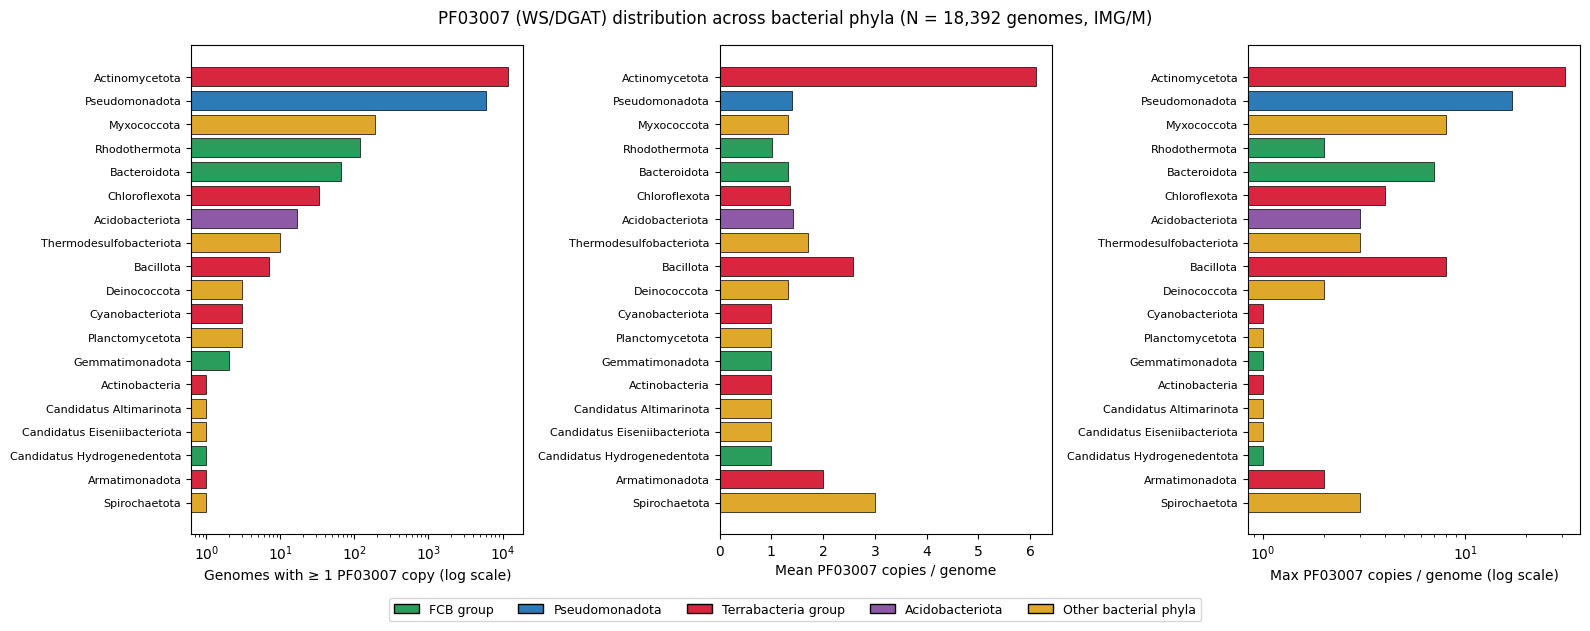

In [4]:
phylum_colors = phylum_stats['taxon_group'].map(group_colors)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = [
    ('n_genomes', 'Genomes with \u2265 1 PF03007 copy (log scale)', True),
    ('mean_copies', 'Mean PF03007 copies / genome', False),
    ('max_copies', 'Max PF03007 copies / genome (log scale)', True),
]
for ax, (col, label, logscale) in zip(axes, metrics):
    ax.barh(phylum_stats.index, phylum_stats[col], color=phylum_colors, edgecolor='black', linewidth=0.5)
    ax.invert_yaxis()
    if logscale:
        ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.tick_params(axis='y', labelsize=8)

legend_elems = [Patch(facecolor=c, edgecolor='black', label=g) for g, c in group_colors.items()]
fig.legend(handles=legend_elems, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), fontsize=9)
fig.suptitle(f'PF03007 (WS/DGAT) distribution across bacterial phyla (N = {len(genomes):,} genomes, IMG/M)', fontsize=12)
plt.tight_layout()
plt.savefig('figure6_bacterial_genomes_pf03007_by_phylum.png', dpi=300, bbox_inches='tight')
plt.savefig('figure6_bacterial_genomes_pf03007_by_phylum.svg', bbox_inches='tight')
plt.show()


Actinomycetota and Pseudomonadota account for the large majority of genomes carrying PF03007, consistent with their status as the most frequently reported hosts of WS/DGAT-type enzymes. Actinomycetota also stands out in copy number, with a mean well above every other phylum — this phylum is examined in more detail at the class level below.


## 3. Distribution across bacterial classes (Figure 7)

The same three metrics, resolved at the class level and colored by parent phylum/taxonomic group. This is the resolution at which copy-number differences become most informative — e.g. distinguishing which class within Actinomycetota or Pseudomonadota drives the phylum-level signal.


In [5]:
class_stats = genomes.groupby(['phylum', 'class']).agg(
    n_genomes=('img_genome_id', 'nunique'),
    mean_copies=('pf03007_count', 'mean'),
    max_copies=('pf03007_count', 'max'),
).round(2).reset_index()
class_stats['taxon_group'] = class_stats['phylum'].map(taxon_group_map).fillna('Other bacterial phyla')
class_stats['class_label'] = class_stats.apply(
    lambda r: r['class'] if r['class'].startswith('unclassified (') else f"{r['class']} ({r['phylum']})",
    axis=1
)
class_stats = class_stats.sort_values('n_genomes', ascending=False).reset_index(drop=True)
print(f"Class-level groups: {len(class_stats)}")
class_stats.head(10)


Class-level groups: 43


,phylum,class,n_genomes,mean_copies,max_copies,taxon_group,class_label
0,Actinomycetota,Actinomycetes,10053,6.94,31,Terrabacteria group,Actinomycetes (Actinomycetota)
1,Pseudomonadota,Gammaproteobacteria,3987,1.41,17,Pseudomonadota,Gammaproteobacteria (Pseudomonadota)
2,Actinomycetota,unclassified (Actinomycetota),1827,1.61,13,Terrabacteria group,unclassified (Actinomycetota)
3,Pseudomonadota,Alphaproteobacteria,1274,1.22,9,Pseudomonadota,Alphaproteobacteria (Pseudomonadota)
4,Pseudomonadota,Betaproteobacteria,720,1.55,11,Pseudomonadota,Betaproteobacteria (Pseudomonadota)
5,Myxococcota,Myxococcia,163,1.27,8,Other bacterial phyla,Myxococcia (Myxococcota)
6,Rhodothermota,Rhodothermia,120,1.02,2,FCB group,Rhodothermia (Rhodothermota)
7,Bacteroidota,Flavobacteriia,56,1.25,7,FCB group,Flavobacteriia (Bacteroidota)
8,Actinomycetota,Thermoleophilia,30,4.20,9,Terrabacteria group,Thermoleophilia (Actinomycetota)
9,Myxococcota,unclassified (Myxococcota),28,1.61,7,Other bacterial phyla,unclassified (Myxococcota)


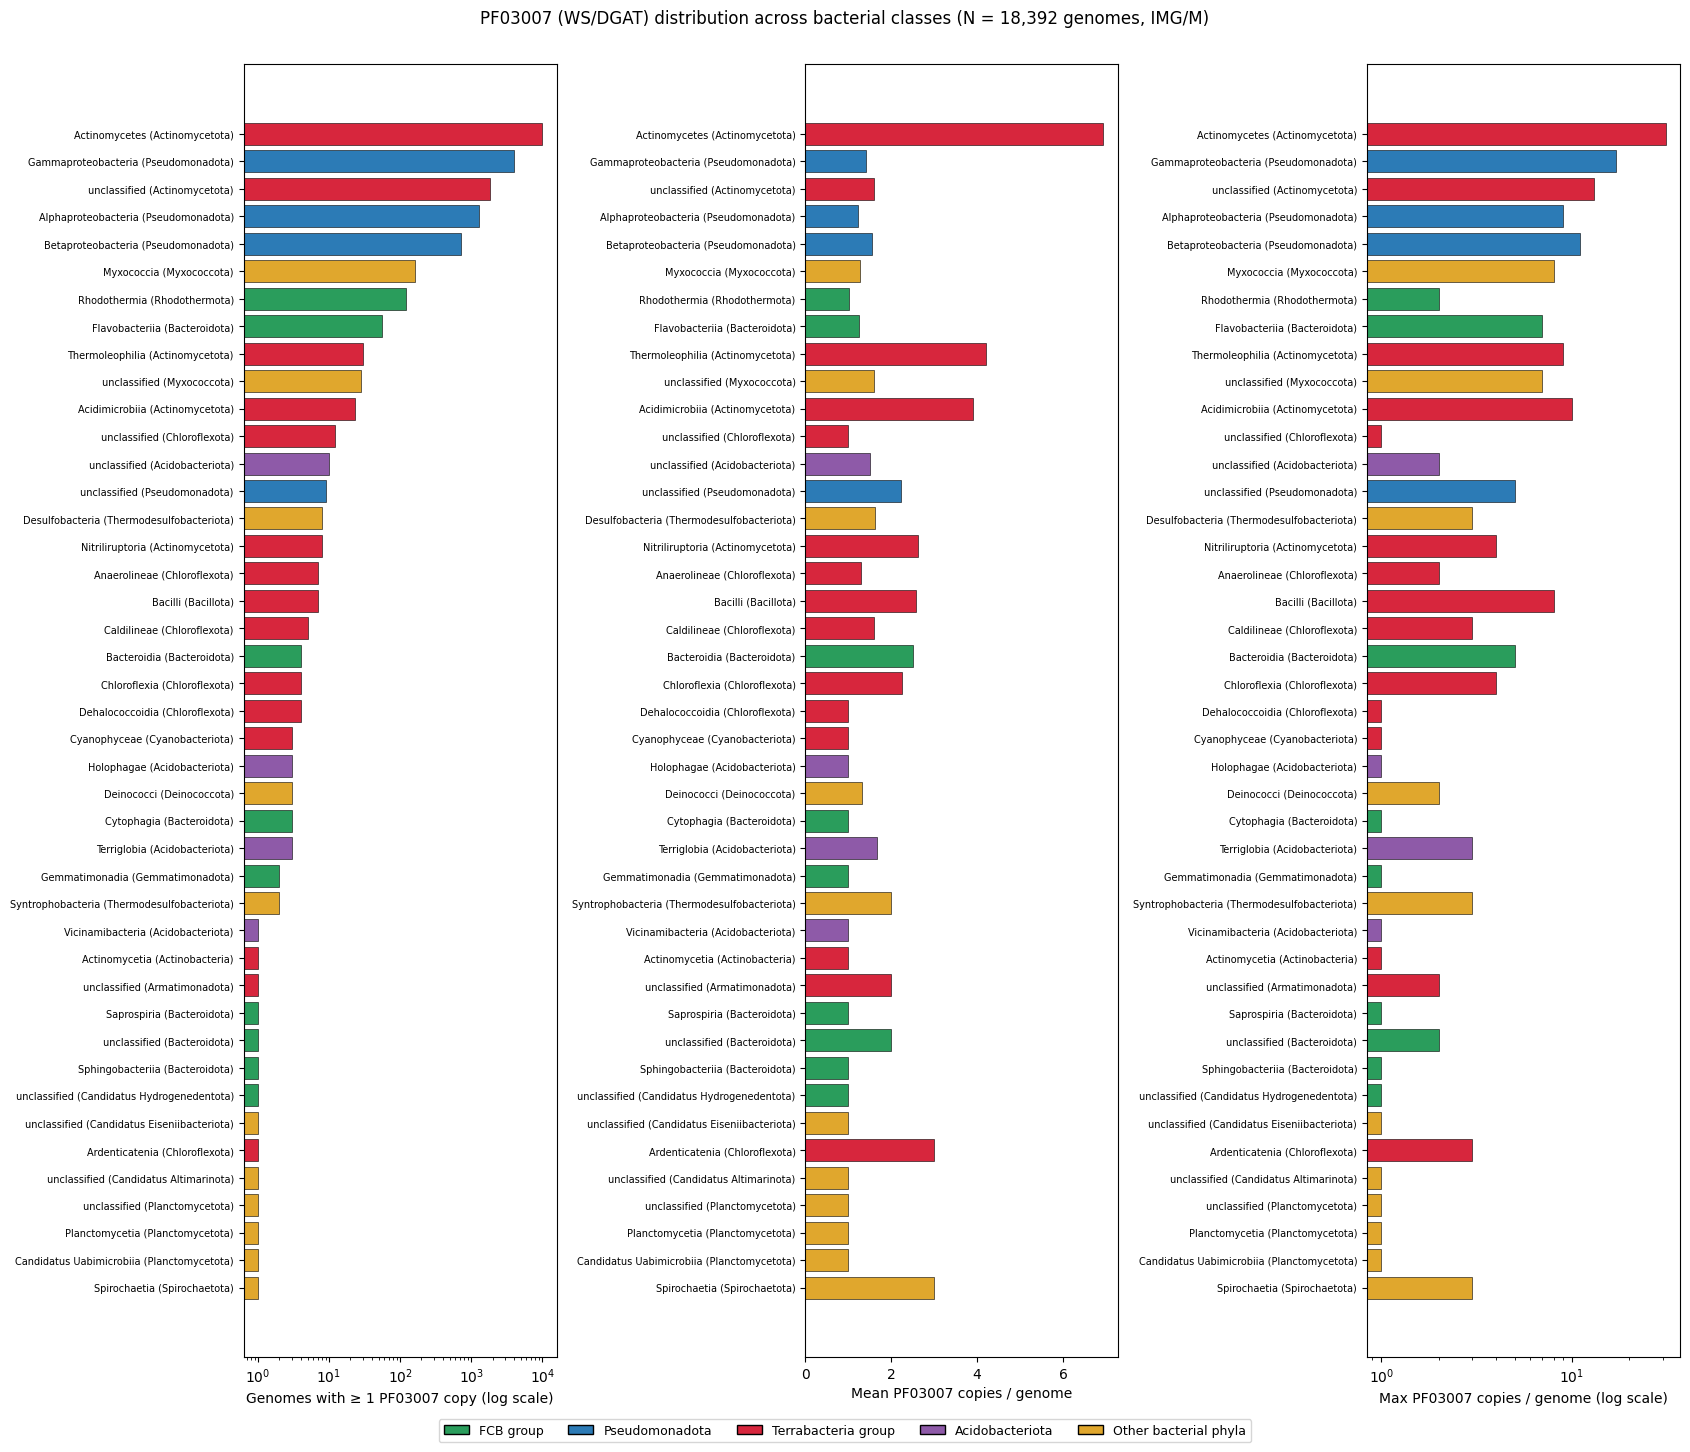

In [6]:
class_colors = class_stats['taxon_group'].map(group_colors)

fig, axes = plt.subplots(1, 3, figsize=(17, 0.28 * len(class_stats) + 2))
metrics = [
    ('n_genomes', 'Genomes with \u2265 1 PF03007 copy (log scale)', True),
    ('mean_copies', 'Mean PF03007 copies / genome', False),
    ('max_copies', 'Max PF03007 copies / genome (log scale)', True),
]
for ax, (col, label, logscale) in zip(axes, metrics):
    ax.barh(class_stats['class_label'], class_stats[col], color=class_colors, edgecolor='black', linewidth=0.4)
    ax.invert_yaxis()
    if logscale:
        ax.set_xscale('log')
    ax.set_xlabel(label, fontsize=10)
    ax.tick_params(axis='y', labelsize=7)

legend_elems = [Patch(facecolor=c, edgecolor='black', label=g) for g, c in group_colors.items()]
fig.legend(handles=legend_elems, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle(f'PF03007 (WS/DGAT) distribution across bacterial classes (N = {len(genomes):,} genomes, IMG/M)', fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig('figure7_bacterial_genomes_pf03007_by_class.png', dpi=300, bbox_inches='tight')
plt.savefig('figure7_bacterial_genomes_pf03007_by_class.svg', bbox_inches='tight')
plt.show()


The five classes with the largest number of PF03007-carrying genomes:


In [7]:
top5 = class_stats.head(5)[['phylum', 'class', 'n_genomes', 'mean_copies', 'max_copies']]
top5


,phylum,class,n_genomes,mean_copies,max_copies
0,Actinomycetota,Actinomycetes,10053,6.94,31
1,Pseudomonadota,Gammaproteobacteria,3987,1.41,17
2,Actinomycetota,unclassified (Actinomycetota),1827,1.61,13
3,Pseudomonadota,Alphaproteobacteria,1274,1.22,9
4,Pseudomonadota,Betaproteobacteria,720,1.55,11


## 4. Genome-level examples of biotechnological interest

Two well-characterized Actinomycetota species illustrate what these copy numbers look like at the individual-genome level: *Mycobacterium tuberculosis* H37Rv (reference pathogen strain) and *Rhodococcus opacus* PD630 (an oleaginous soil bacterium known to accumulate triacylglycerols at high proportions of its biomass).


In [8]:
examples = genomes[
    genomes['genome_name'].str.contains('tuberculosis H37Rv', case=False, na=False) & (genomes['sequencing_status'] == 'Finished')
    | genomes['genome_name'].str.contains('opacus PD630', case=False, na=False)
][['img_genome_id', 'genome_name', 'phylum', 'class', 'pf03007_count', 'sequencing_status']]
examples


,img_genome_id,genome_name,phylum,class,pf03007_count,sequencing_status
811,2547132199,Rhodococcus opacus PD630,Actinomycetota,Actinomycetes,16,Permanent Draft
2033,2576861435,Rhodococcus opacus PD630,Actinomycetota,Actinomycetes,15,Finished
4325,2645727865,Mycobacterium tuberculosis H37RvSiena,Actinomycetota,Actinomycetes,14,Finished


Both species carry multiple PF03007 copies well above the phylum-wide mean, consistent with *R. opacus*'s known oleaginous phenotype and with Actinomycetota's overall enrichment for this domain.


## 5. Export summary tables

Phylum- and class-level statistics, exported for reuse. The genome-level dataset (`bacterial_genomes_pf03007_repo1.csv`, loaded in Section 1) already carries the IMG Genome ID for every individual genome referenced in these summaries.


In [9]:
phylum_export = phylum_stats.reset_index().rename(columns={
    'phylum': 'Phylum', 'n_genomes': 'N genomes (>=1 PF03007 copy)',
    'mean_copies': 'Mean PF03007 copies per genome', 'max_copies': 'Max PF03007 copies per genome',
    'taxon_group': 'Taxonomic group'
})
phylum_export.to_csv('bacterial_genomes_phylum_summary_repo1.csv', index=False)

class_export = class_stats[['phylum', 'class', 'n_genomes', 'mean_copies', 'max_copies', 'taxon_group']].rename(columns={
    'phylum': 'Phylum', 'class': 'Class', 'n_genomes': 'N genomes (>=1 PF03007 copy)',
    'mean_copies': 'Mean PF03007 copies per genome', 'max_copies': 'Max PF03007 copies per genome',
    'taxon_group': 'Taxonomic group'
})
class_export.to_csv('bacterial_genomes_class_summary_repo1.csv', index=False)

print(f"Saved: bacterial_genomes_phylum_summary_repo1.csv ({phylum_export.shape[0]} rows)")
print(f"Saved: bacterial_genomes_class_summary_repo1.csv ({class_export.shape[0]} rows)")


Saved: bacterial_genomes_phylum_summary_repo1.csv (19 rows)
Saved: bacterial_genomes_class_summary_repo1.csv (43 rows)


## 6. Key findings

1. PF03007 was identified in **18,392 bacterial genomes** across **19 phyla** in IMG/M, totaling **81,868 gene copies** — confirming that WS/DGAT-type biosynthetic potential is broad but taxonomically uneven.
2. **Actinomycetota and Pseudomonadota** dominate by genome count (11,941 and 5,990 genomes respectively), together accounting for the large majority of PF03007-carrying genomes.
3. **Actinomycetota also carries the highest copy number per genome** (mean 6.11, driven almost entirely by the class Actinomycetes: mean 6.94, up to 31 copies in a single genome) — a much stronger enrichment than genome count alone would suggest.
4. Within Pseudomonadota, **Gammaproteobacteria** carries both the most genomes (3,987) and the highest copy numbers (up to 17 per genome) of the class.
5. Several less-studied phyla — **Myxococcota, Rhodothermota, Bacteroidota** — contribute a non-trivial number of PF03007-carrying genomes (191, 120, and 66 respectively), indicating the domain's distribution extends beyond the two dominant phyla.
6. At the individual-genome level, both *M. tuberculosis* H37Rv and the oleaginous species *R. opacus* PD630 carry multiple PF03007 copies, well above their phylum-wide average — consistent with elevated neutral-lipid biosynthetic capacity in organisms already known for this trait.


## References

- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*. https://doi.org/10.1371/journal.pone.0288509
- Chen, I-M. A. et al. (2021). The IMG/M data management and analysis system v.6.0: new tools and advanced capabilities. *Nucleic Acids Research*, 49(D1), D751–D763. https://doi.org/10.1093/nar/gkaa939
